# Question 3
-------
In this exercise you will compare three image denoising methods:
- Gaussian linear filtering 
- Bilateral filtering
Use a standard grayscale test image (for example cameraman)


## Setup 
-----
1. Load a grayscale image $f$ and scale intensities to the interval $[0, 1]$
2. Create a noisy observation 
$$g=f+\eta$$
$$\eta[n, m]\approx \mathcal{N}(0, \sigma^2)$$

for two noise levels, for example $\sigma \in \{0.05, 0.10\}$. To this end, use the `randn` function for noise generation.



In [14]:
# Imports
import numpy as np
import cv2
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse

In [15]:
# Setup
# 1. Load the clean image (f)
f = cv2.imread('Cameraman.png', cv2.IMREAD_GRAYSCALE)
f = f.astype(np.float64) / 255.0  # Scale to [0, 1]

# 2. Define noise levels
sigmaNoise = [0.05, 0.10]

# Smoothening Strength
sigmaG = 1.2

# 3. Generate noise (eta)
# Using the same shape as f
eta1 = sigmaNoise[0] * np.random.randn(*f.shape)
eta2 = sigmaNoise[1] * np.random.randn(*f.shape)

# 4. Create noisy observations (g)
g1 = f + eta1
g2 = f + eta2

# Note: We should clip the results to [0, 1] for visualization
g1Clipped = np.clip(g1, 0, 1)
g2Clipped = np.clip(g2, 0, 1)


## Gaussian Linear Filtering
--------
Implement Gaussian smoothing using a two-dimensional Gaussian kernel

$$h[n, m]\propto e^{-\frac{m^2+n^2}{2\sigma^2_g}}$$

You may use MATLAB/NumPy functions to generate the impulse response of the Gaussian filter. Choose the kernel size as a function of $\sigma_g$ (for example, $6\sigma_g + 1$) and apply the filter using two-dimensional convolution.



In [16]:
def ApplyGaussianFilter(noisy_img, sigma_g):
    # Determine kernel size (6*sigma + 1) and make it odd
    kSize = int(6 * sigma_g + 1)
    
    if kSize % 2 == 0: 
        kSize += 1
    
    # Create a 1D coordinate array centered at 0
    ax = np.linspace(-(kSize - 1) / 2, (kSize - 1) / 2, kSize)
    
    # Generate 1D Gaussian and take outer product for 2D
    gauss1d = np.exp(-0.5 * np.square(ax) / np.square(sigma_g))
    kernel2d = np.outer(gauss1d, gauss1d)
    
    # Normalize the kernel so weights sum to 1
    kernel2d = kernel2d / np.sum(kernel2d)
    
    # Apply 2D convolution with symmetric boundary padding
    return convolve2d(noisy_img, kernel2d, mode='same', boundary='symm')

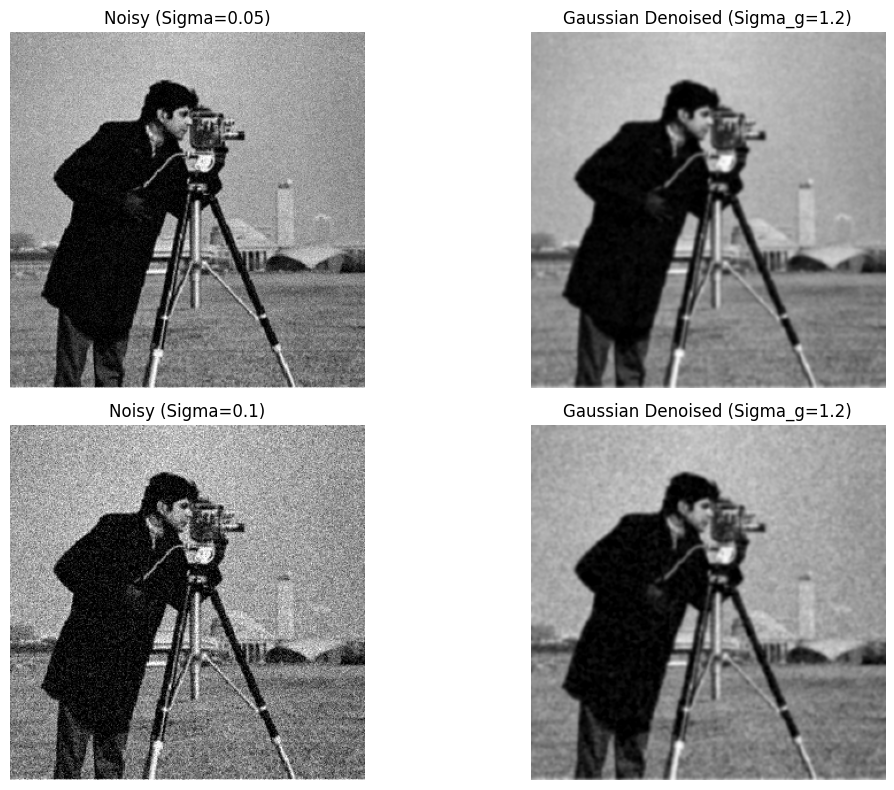

In [17]:
# Run the code and display the denoising for different Sigmas
plt.figure(figsize=(12, 8))

for i, sn in enumerate(sigmaNoise):
    # Create Noise
    noise = sn * np.random.randn(*f.shape)
    g = f + noise
    
    # Apply Filter
    f_hat = ApplyGaussianFilter(g, sigmaG)
    
    # Plot Noisy vs Denoised
    plt.subplot(2, 2, i*2 + 1)
    plt.imshow(np.clip(g, 0, 1), cmap='gray')
    plt.title(f"Noisy (Sigma={sn})")
    plt.axis('off')
    
    plt.subplot(2, 2, i*2 + 2)
    plt.imshow(np.clip(f_hat, 0, 1), cmap='gray')
    plt.title(f"Gaussian Denoised (Sigma_g={sigmaG})")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Bilateral Filtering
-------
Implement the bilateral filter :
$$\hat{f}[n,m] = \frac{1}{Z_{n,m}} \sum_{(i,j) \in \mathcal{N}} e^{\left( -\frac{(n-i)^2 + (m-j)^2}{2\sigma_s^2} \right)} e^{\left( -\frac{(g[m,n] - g[i,j])^2}{2\sigma_r^2} \right)} g[i,j],$$

where $\mathcal{N}$ is a finite neighborhood around the pixel (n,m) and the normalization constant $Z_{n, m}$ ensures that the filter weights sum to one :
$$Z_{n,m} = \sum_{(i,j) \in \mathcal{N}} e^{\left( -\frac{(n-i)^2 + (m-j)^2}{2\sigma_s^2} \right)} e^{\left( -\frac{(g[m,n] - g[i,j])^2}{2\sigma_r^2} \right)}$$

The parameter $\sigma_s$ controls the spatial weighting, while $\sigma_r$ controls the sensitivity to intensity differences. Pixels that are both spatially close and have similar intensity values receive the largest weights.

Use a square neighborhood $\mathcal{N}$ centered at (m,n). A reasonable choice is :
$$(2K + 1) \times (2K + 1), \quad K \approx 2\sigma_s,$$

so that the spatial Gaussian is effectively truncated outside this region. 

Typical parameter ranges are:
- $\sigma_s \in [1, 5]$ pixels, 
- $\sigma_r \in [0.05, 0.20]$ (assuming image intensities are scaled to $[0,1]$), 
- Neighborhood size $(2K +1) \times(2K +1)$ with $K \approx 2\sigma_s$.

You may explore different parameter values and select those providing good denoising performance. 

In MATLAB, one convenient implementation strategy is to apply a local nonlinear function to each neighborhood using the function `nlfilter`. In Python/NumPy, an analogous implementation may be constructed using sliding-window operations or explicit neighborhood loops.

1. Implement the bilateral filter described above. Clearly state the values of $\sigma_s$, $\sigma_r$ and the neighborhood size used in your implementation.
2. Experiment with several values of $\sigma_s$, $\sigma_r$ within the suggested ranges and select parameters that provide good denoising performance.
3. Apply the bilateral filter to the noisy images for both noise levels.
4. Compare the denoised results with those obtained using Gaussian filtering in terms of MMSE and SSIM.
5. Comment briefly on the computational complexity of bilateral filtering compared to Gaussian filtering.


In [18]:
def ManualBilateralFilter(img, sigmaS, sigmaR):
    K = int(2 * sigmaS)
    size = 2 * K + 1
    pad = K
    imgPad = np.pad(img, pad, mode='reflect')
    out = np.zeros_like(img)
    
    # Pre-calculate spatial Gaussian weights (constant for all pixels)
    y, x = np.ogrid[-K:K+1, -K:K+1]
    spatial_weights = np.exp(-(x**2 + y**2) / (2 * sigmaS**2))
    
    # Iterate through every pixel (explicit neighborhood loop)
    for n in range(img.shape[0]):
        for m in range(img.shape[1]):
            # Get local neighborhood
            region = imgPad[n:n+size, m:m+size]
            centerVal = img[n, m]
            
            # Calculate range weights based on intensity difference
            range_weights = np.exp(-(region - centerVal)**2 / (2 * sigmaR**2))
            
            # Combined weights
            weights = spatial_weights * range_weights
            
            # Normalize and apply
            Z = np.sum(weights)
            out[n, m] = np.sum(weights * region) / Z
            
    return out

--- Experiment Parameters ---
Bilateral: sigma_s=2.0, sigma_r=0.12, Neighborhood=9x9
Gaussian:  sigma_g=1.2

Processing noise level sigma=0.05...
Processing noise level sigma=0.1...
Noise Sigma  | Method     | MSE      | SSIM    
---------------------------------------------
0.05         | Gaussian   | 0.0017   | 0.8435  
             | Bilateral  | 0.0007   | 0.8651  
---------------------------------------------
0.10         | Gaussian   | 0.0021   | 0.7143  
             | Bilateral  | 0.0032   | 0.4862  
---------------------------------------------


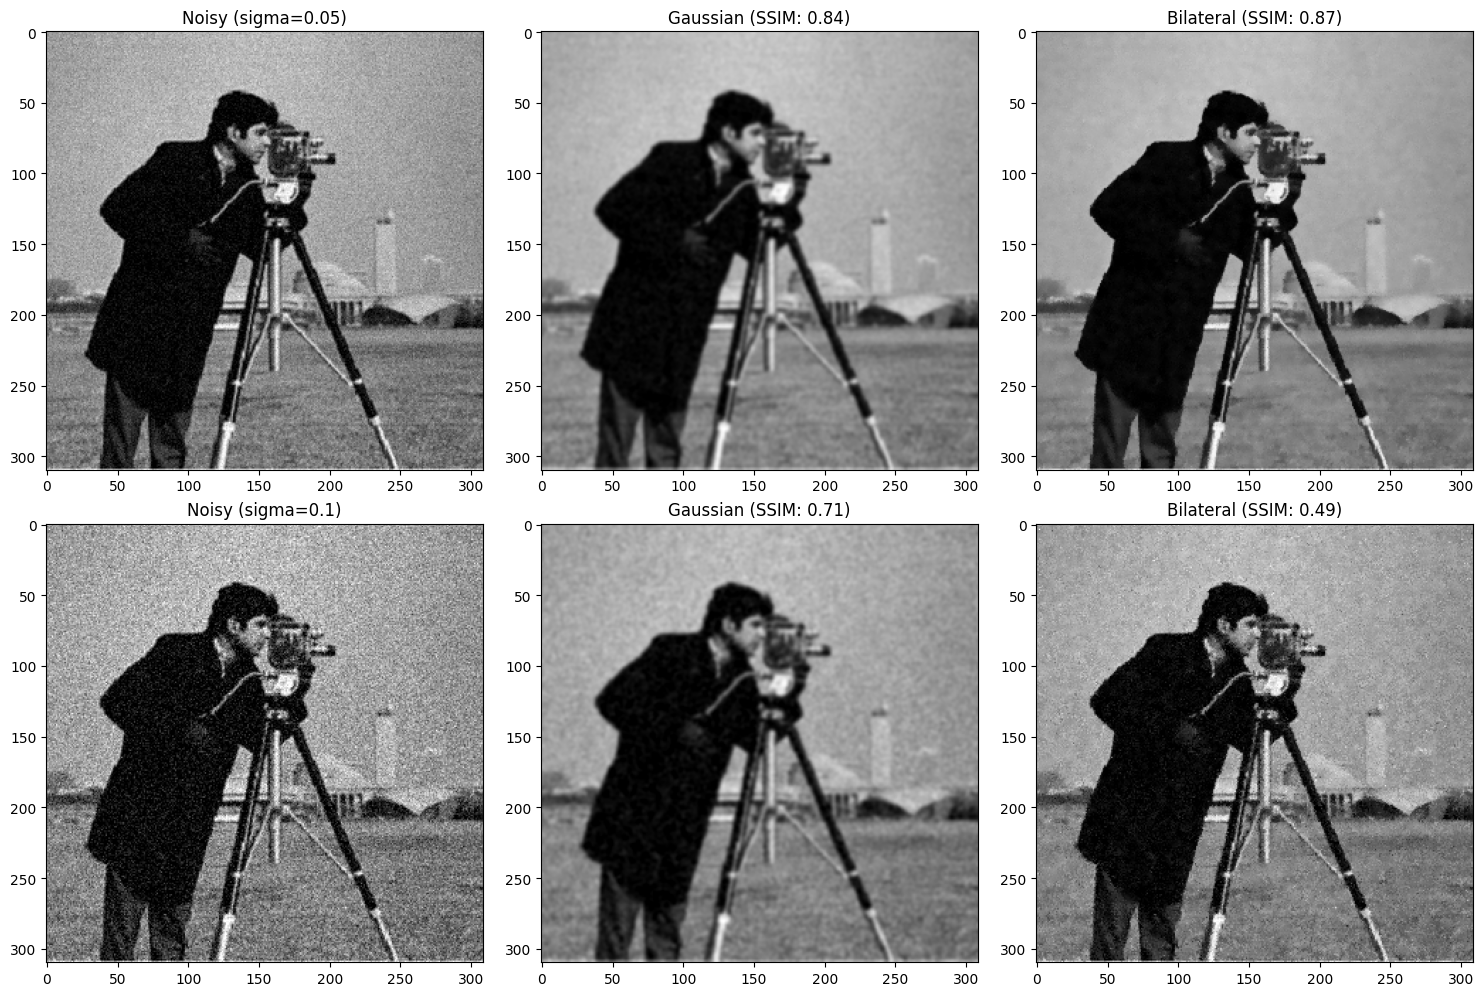

In [19]:
# Parameters for testing
noise_levels = [0.05, 0.10]

# Selected Denoising Parameters (based on experiments)
sigma_g = 1.2
sigma_s = 2.0
sigma_r = 0.12
K = int(2 * sigma_s)
nb_size = (2*K + 1)

print(f"--- Experiment Parameters ---")
print(f"Bilateral: sigma_s={sigma_s}, sigma_r={sigma_r}, Neighborhood={nb_size}x{nb_size}")
print(f"Gaussian:  sigma_g={sigma_g}\n")

results = []

for sn in noise_levels:
    # Create noisy observation g = f + eta
    eta = sn * np.random.randn(*f.shape)
    g = f + eta
    
    # Apply Filters
    print(f"Processing noise level sigma={sn}...")
    f_gauss = ApplyGaussianFilter(g, sigma_g)
    f_bilat = ManualBilateralFilter(g, sigma_s, sigma_r)
    
    # Calculate Metrics
    mse_g = mse(f, f_gauss)
    ssim_g = ssim(f, f_gauss, data_range=1.0)
    
    mse_b = mse(f, f_bilat)
    ssim_b = ssim(f, f_bilat, data_range=1.0)
    
    results.append({
        'sn': sn, 'g': g, 
        'f_gauss': f_gauss, 'mse_g': mse_g, 'ssim_g': ssim_g,
        'f_bilat': f_bilat, 'mse_b': mse_b, 'ssim_b': ssim_b
    })

# Output Results Table
print(f"{'Noise Sigma':<12} | {'Method':<10} | {'MSE':<8} | {'SSIM':<8}")
print("-" * 45)
for res in results:
    print(f"{res['sn']:<12.2f} | {'Gaussian':<10} | {res['mse_g']:<8.4f} | {res['ssim_g']:<8.4f}")
    print(f"{' ': <12} | {'Bilateral':<10} | {res['mse_b']:<8.4f} | {res['ssim_b']:<8.4f}")
    print("-" * 45)

# Final Visualization
fig, axes = plt.subplots(len(noise_levels), 3, figsize=(15, 10))
for i, res in enumerate(results):
    axes[i, 0].imshow(np.clip(res['g'], 0, 1), cmap='gray')
    axes[i, 0].set_title(f"Noisy (sigma={res['sn']})")
    axes[i, 1].imshow(np.clip(res['f_gauss'], 0, 1), cmap='gray')
    axes[i, 1].set_title(f"Gaussian (SSIM: {res['ssim_g']:.2f})")
    axes[i, 2].imshow(np.clip(res['f_bilat'], 0, 1), cmap='gray')
    axes[i, 2].set_title(f"Bilateral (SSIM: {res['ssim_b']:.2f})")

plt.tight_layout()
plt.show()

In [20]:
sigmaS = 2.0
sigmaR = 0.12
sigmaG = 1.2

fBilat = ManualBilateralFilter(g, sigmaS=sigmaS, sigmaR=sigmaR)
fGauss = ApplyGaussianFilter(g, sigma_g=sigmaG)

# Calculate Metrics
mseG = mse(f, fGauss)
ssimG = ssim(f, fGauss, data_range=1.0)

mseB = mse(f, fBilat)
ssimB = ssim(f, fBilat, data_range=1.0)

print(f"Gaussian -> MSE: {mseG:.4f}, SSIM: {ssimG:.4f}")
print(f"Bilateral -> MSE: {mseB:.4f}, SSIM: {ssimB:.4f}")

Gaussian -> MSE: 0.0021, SSIM: 0.7143
Bilateral -> MSE: 0.0032, SSIM: 0.4862
